 [OK] Dataset cargado: 1461 registros meteorológicos.



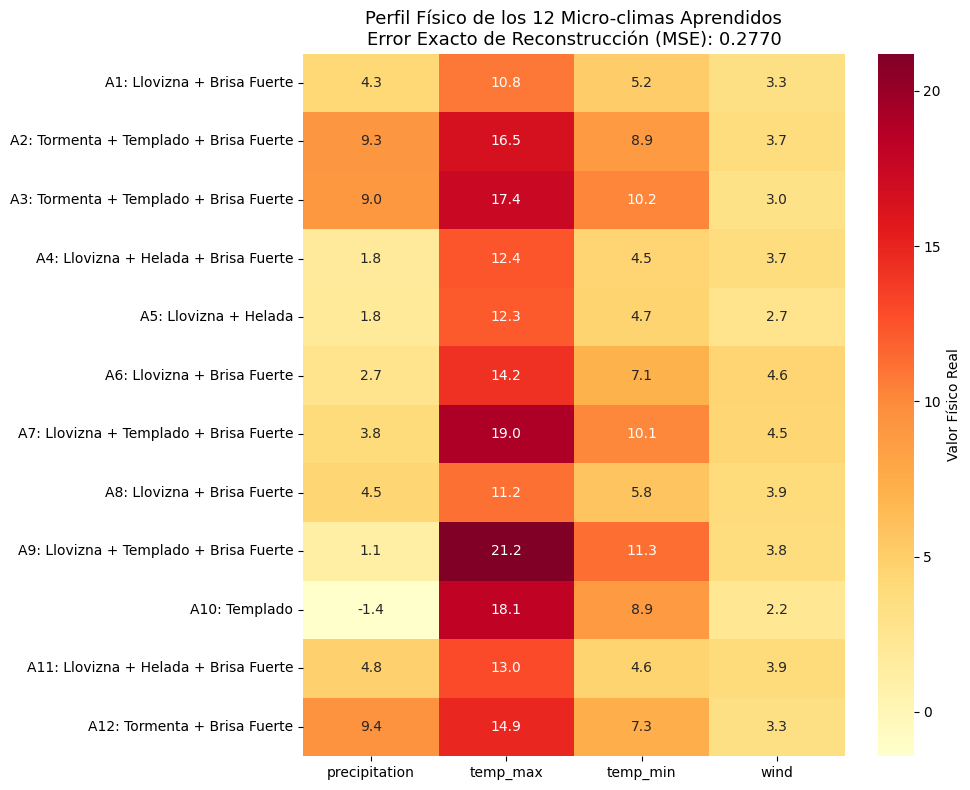

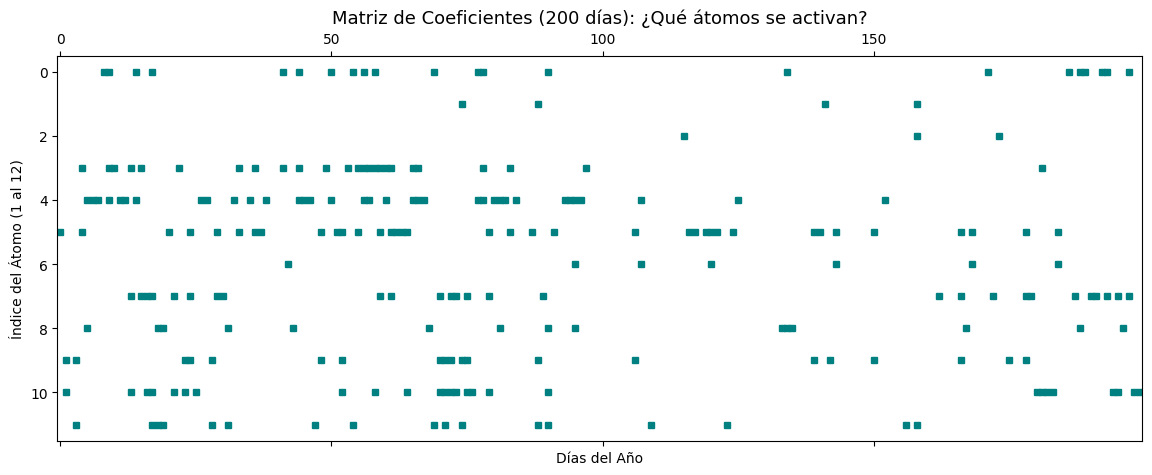

 ANÁLISIS DE EFICIENCIA Y COMPRESIÓN
 Error Cuadrático Medio (MSE): 0.2770
 Nivel de esparcidad:        89.49% de ceros exactos.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# ==========================================
# 1) IMPORTACIÓN Y PREPARACIÓN DEL DATASET
# ==========================================
url = "https://raw.githubusercontent.com/vega/vega/main/docs/data/seattle-weather.csv"

try:
    data = pd.read_csv(url)
    features = ['precipitation', 'temp_max', 'temp_min', 'wind']
    X_raw = data[features].dropna()
    print(f" [OK] Dataset cargado: {X_raw.shape[0]} registros meteorológicos.\n")
except Exception as e:
    print(f" [ERROR] No se pudo acceder a los datos: {e}")
    exit()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# =========================================================
# 2) APRENDIZAJE DE DICCIONARIO (12 ÁTOMOS)
# =========================================================
# Aumentamos a 12 para buscar patrones meteorológicos sutiles
n_atoms = 12
dict_learner = DictionaryLearning(
    n_components=n_atoms, 
    alpha=1.0, 
    transform_algorithm='lasso_lars', 
    random_state=42,
    max_iter=1000
)

sparse_representation = dict_learner.fit_transform(X_scaled)
dictionary_atoms = dict_learner.components_

# Cálculo de la solución exacta del error (MSE, sin raíces)
X_reconstructed_scaled = np.dot(sparse_representation, dictionary_atoms)
mse_exacto = mean_squared_error(X_scaled, X_reconstructed_scaled)

# =========================================================
# 3) INTERPRETACIÓN Y ETIQUETADO
# =========================================================
interpreted_atoms = scaler.inverse_transform(dictionary_atoms)
df_atoms = pd.DataFrame(interpreted_atoms, columns=features)

def asignar_nombre_meteorologico(row):
    labels = []
    if row['precipitation'] > 5: labels.append("Tormenta")
    elif row['precipitation'] > 1: labels.append("Llovizna")
    
    if row['temp_max'] > 25: labels.append("Muy Cálido")
    elif row['temp_max'] > 15: labels.append("Templado")
    
    if row['temp_min'] < 5: labels.append("Helada")
    
    if row['wind'] > 6: labels.append("Vendaval")
    elif row['wind'] > 3: labels.append("Brisa Fuerte")
    
    return " + ".join(labels) if labels else "Día Neutro"

# Numeramos los átomos del 1 al 12 para mayor claridad
nombres_logicos = [f"A{i+1}: {asignar_nombre_meteorologico(row)}" for i, row in df_atoms.iterrows()]
df_atoms.index = nombres_logicos

# =========================================================
# 4) VISUALIZACIÓN DE RESULTADOS
# =========================================================
# Gráfico 1: Heatmap más alto para acomodar las 12 filas
plt.figure(figsize=(10, 8))
sns.heatmap(df_atoms, annot=True, cmap="YlOrRd", fmt=".1f", cbar_kws={'label': 'Valor Físico Real'})
plt.title(f"Perfil Físico de los {n_atoms} Micro-climas Aprendidos\nError Exacto de Reconstrucción (MSE): {mse_exacto:.4f}", fontsize=13)
plt.tight_layout()
plt.show()

# Gráfico 2: Esparcidad de la Matriz de Coeficientes
plt.figure(figsize=(14, 5))
plt.spy(sparse_representation[:200].T, precision=0.01, aspect='auto', marker='s', markersize=5, color='teal')
plt.title("Matriz de Coeficientes (200 días): ¿Qué átomos se activan?", fontsize=13)
plt.ylabel("Índice del Átomo (1 al 12)")
plt.xlabel("Días del Año")
plt.show()

# =========================================================
# 5) MÉTRICAS EXACTAS FINALES
# =========================================================
ceros_exactos = np.sum(np.abs(sparse_representation) < 1e-5)
sparsity_pct = (ceros_exactos / sparse_representation.size) * 100

print("="*60)
print(" ANÁLISIS DE EFICIENCIA Y COMPRESIÓN")
print("="*60)
print(f" Error Cuadrático Medio (MSE): {mse_exacto:.4f}")
print(f" Nivel de esparcidad:        {sparsity_pct:.2f}% de ceros exactos.")
print("="*60)

Cargando el dataset del clima de Seattle...
Dataset listo: 1461 días, 4 variables físicas.
------------------------------------------------------------
Entrenando diccionarios y calculando métricas exactas...
Átomos:  1 | MSE Exacto: 0.7847 | Esparcidad: 82.41%
Átomos:  2 | MSE Exacto: 0.4905 | Esparcidad: 66.97%
Átomos:  3 | MSE Exacto: 0.3811 | Esparcidad: 68.13%
Átomos:  4 | MSE Exacto: 0.3322 | Esparcidad: 74.69%
Átomos:  5 | MSE Exacto: 0.3227 | Esparcidad: 78.92%
Átomos:  6 | MSE Exacto: 0.3117 | Esparcidad: 81.61%
Átomos:  7 | MSE Exacto: 0.2997 | Esparcidad: 83.57%
Átomos:  8 | MSE Exacto: 0.2906 | Esparcidad: 85.24%
Átomos:  9 | MSE Exacto: 0.2870 | Esparcidad: 86.68%
Átomos: 10 | MSE Exacto: 0.2828 | Esparcidad: 87.72%
Átomos: 11 | MSE Exacto: 0.2806 | Esparcidad: 88.94%
Átomos: 12 | MSE Exacto: 0.2770 | Esparcidad: 89.49%
------------------------------------------------------------


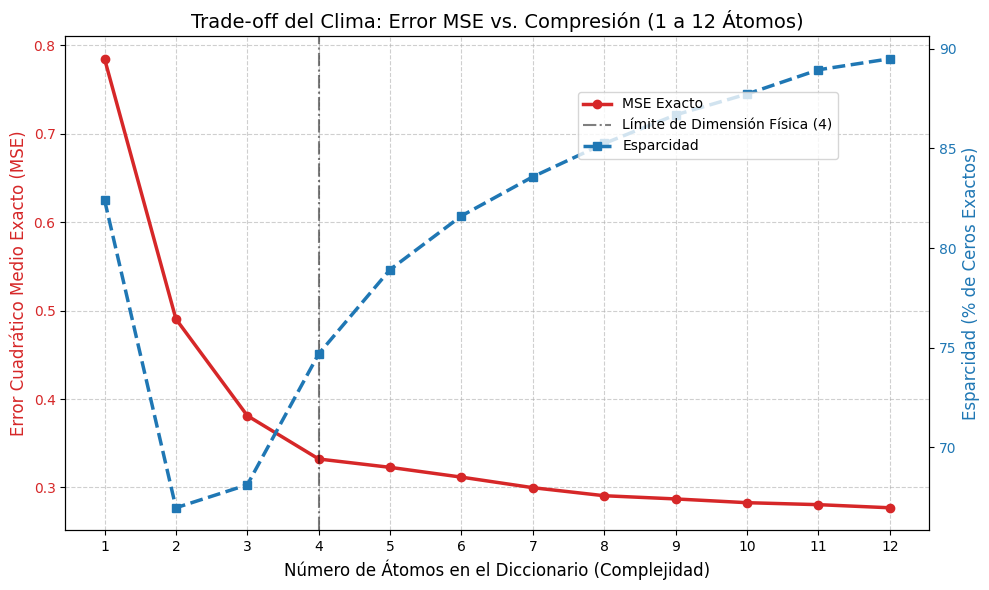

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# ==========================================
# 1) IMPORTACIÓN Y PREPARACIÓN DEL DATASET
# ==========================================
print("Cargando el dataset del clima de Seattle...")
url = "https://raw.githubusercontent.com/vega/vega/main/docs/data/seattle-weather.csv"
data = pd.read_csv(url)
features = ['precipitation', 'temp_max', 'temp_min', 'wind']
X_raw = data[features].dropna()

# Normalización indispensable
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Dataset listo: {X_scaled.shape[0]} días, {X_scaled.shape[1]} variables físicas.")
print("-" * 60)

# ==========================================
# 2) BUCLE DE EXPERIMENTACIÓN (1 a 12 ÁTOMOS)
# ==========================================
rango_atomos = range(1, 13)
resultados_mse = []
resultados_esparcidad = []

print("Entrenando diccionarios y calculando métricas exactas...")

for n_atoms in rango_atomos:
    # Entrenar el diccionario
    dict_learner = DictionaryLearning(
        n_components=n_atoms, 
        alpha=1.0, 
        transform_algorithm='lasso_lars', 
        random_state=42,
        max_iter=1000
    )
    
    # Obtener matriz esparsa (coeficientes) y diccionario
    sparse_representation = dict_learner.fit_transform(X_scaled)
    dictionary_atoms = dict_learner.components_
    
    # Reconstrucción matemática
    X_reconstructed = np.dot(sparse_representation, dictionary_atoms)
    
    # Cálculo de la solución exacta del error (MSE, sin raíces)
    mse_exacto = mean_squared_error(X_scaled, X_reconstructed)
    resultados_mse.append(mse_exacto)
    
    # Cálculo de la esparcidad exacta (% de ceros)
    ceros_exactos = np.sum(np.abs(sparse_representation) < 1e-5)
    sparsity_pct = (ceros_exactos / sparse_representation.size) * 100
    resultados_esparcidad.append(sparsity_pct)
    
    print(f"Átomos: {n_atoms:2} | MSE Exacto: {mse_exacto:.4f} | Esparcidad: {sparsity_pct:.2f}%")

print("-" * 60)

# ==========================================
# 3) VISUALIZACIÓN: CURVA DE COMPROMISO
# ==========================================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Curva de Error Exacto (MSE) - Eje Izquierdo
color1 = 'tab:red'
ax1.set_xlabel('Número de Átomos en el Diccionario (Complejidad)', fontsize=12)
ax1.set_ylabel('Error Cuadrático Medio Exacto (MSE)', color=color1, fontsize=12)
ax1.plot(rango_atomos, resultados_mse, marker='o', color=color1, linewidth=2.5, label='MSE Exacto')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(rango_atomos)
ax1.grid(True, linestyle='--', alpha=0.6)

# Añadimos una línea vertical en el átomo 4 (límite de dimensiones físicas)
ax1.axvline(x=4, color='black', linestyle='-.', alpha=0.5, label='Límite de Dimensión Física (4)')

# Curva de Esparcidad - Eje Derecho
ax2 = ax1.twinx()  
color2 = 'tab:blue'
ax2.set_ylabel('Esparcidad (% de Ceros Exactos)', color=color2, fontsize=12)
ax2.plot(rango_atomos, resultados_esparcidad, marker='s', color=color2, linewidth=2.5, linestyle='dashed', label='Esparcidad')
ax2.tick_params(axis='y', labelcolor=color2)

# Título y Leyendas
plt.title('Trade-off del Clima: Error MSE vs. Compresión (1 a 12 Átomos)', fontsize=14)
fig.legend(loc="upper right", bbox_to_anchor=(0.85, 0.85))
fig.tight_layout()
plt.show()

Descargando registros climáticos de Lincoln, Nebraska...
Dataset validado: 360 días, 20 dimensiones físicas detectadas.
------------------------------------------------------------
Calculando diccionarios y soluciones exactas de error...


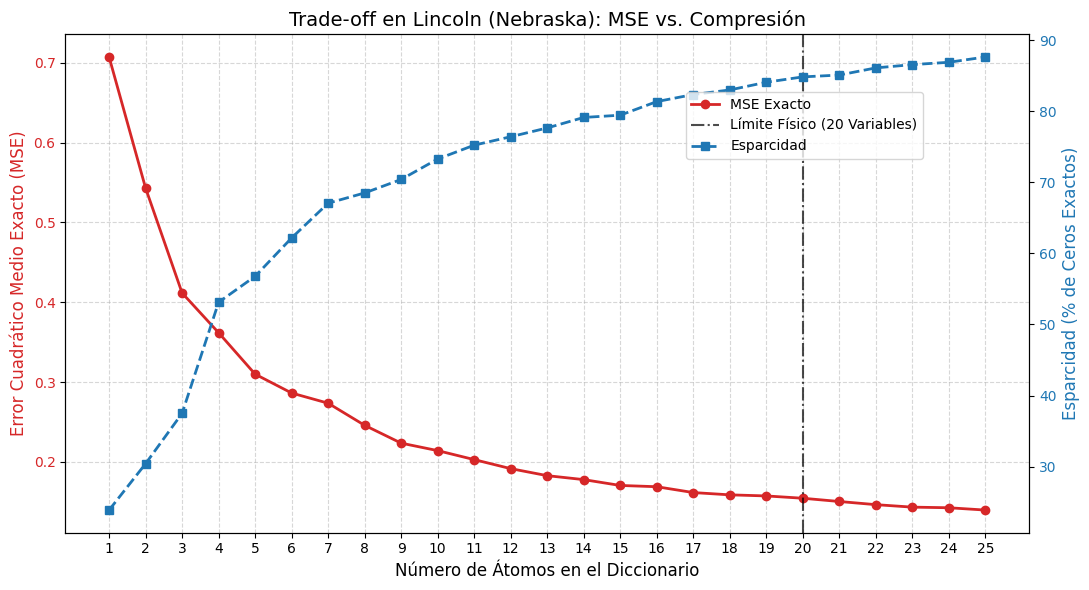

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# ==========================================
# 1) IMPORTACIÓN ROBUSTA DEL NUEVO DATASET
# ==========================================
print("Descargando registros climáticos de Lincoln, Nebraska...")
url = "https://raw.githubusercontent.com/wilkelab/ggridges/master/data-raw/lincoln-weather.csv"

# Leer el CSV directamente desde el repositorio
data = pd.read_csv(url)

# Truco pro: Extraemos SOLO las columnas puramente matemáticas (numéricas) 
# y limpiamos cualquier día que tenga un sensor apagado (nulo).
X_raw = data.select_dtypes(include=[np.number]).dropna()

# Estandarización exacta para que la humedad y la presión tengan el mismo peso
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

dimension_real = X_scaled.shape[1]
print(f"Dataset validado: {X_scaled.shape[0]} días, {dimension_real} dimensiones físicas detectadas.")
print("-" * 60)

# ==========================================
# 2) BUCLE DE PRUEBA: DE 1 A 25 ÁTOMOS
# ==========================================
rango_atomos = range(1, 26)
resultados_mse = []
resultados_esparcidad = []

print("Calculando diccionarios y soluciones exactas de error...")

for n_atoms in rango_atomos:
    dict_learner = DictionaryLearning(
        n_components=n_atoms, 
        alpha=1.0, 
        transform_algorithm='lasso_lars', 
        random_state=42,
        max_iter=1000
    )
    
    # Obtención de coeficientes y diccionario
    sparse_representation = dict_learner.fit_transform(X_scaled)
    dictionary_atoms = dict_learner.components_
    
    # Reconstrucción matemática
    X_reconstructed = np.dot(sparse_representation, dictionary_atoms)
    
    # Evaluación del error cuadrático exacto
    mse_exacto = mean_squared_error(X_scaled, X_reconstructed)
    resultados_mse.append(mse_exacto)
    
    # Cálculo del porcentaje de ceros estrictos
    ceros_exactos = np.sum(np.abs(sparse_representation) < 1e-5)
    sparsity_pct = (ceros_exactos / sparse_representation.size) * 100
    resultados_esparcidad.append(sparsity_pct)

# ==========================================
# 3) GRAFICAR LA NUEVA CURVA DE COMPROMISO
# ==========================================
fig, ax1 = plt.subplots(figsize=(11, 6))

# Curva MSE Exacto
color1 = 'tab:red'
ax1.set_xlabel('Número de Átomos en el Diccionario', fontsize=12)
ax1.set_ylabel('Error Cuadrático Medio Exacto (MSE)', color=color1, fontsize=12)
ax1.plot(rango_atomos, resultados_mse, marker='o', color=color1, linewidth=2, label='MSE Exacto')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(rango_atomos)
ax1.grid(True, linestyle='--', alpha=0.5)

# Dibujamos la línea que marca la barrera matemática de las dimensiones
ax1.axvline(x=dimension_real, color='black', linestyle='-.', alpha=0.7, 
            label=f'Límite Físico ({dimension_real} Variables)')

# Curva Esparcidad
ax2 = ax1.twinx()  
color2 = 'tab:blue'
ax2.set_ylabel('Esparcidad (% de Ceros Exactos)', color=color2, fontsize=12)
ax2.plot(rango_atomos, resultados_esparcidad, marker='s', color=color2, linewidth=2, linestyle='dashed', label='Esparcidad')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Trade-off en Lincoln (Nebraska): MSE vs. Compresión', fontsize=14)
fig.legend(loc="upper right", bbox_to_anchor=(0.85, 0.85))
fig.tight_layout()
plt.show()

Cargando el dataset de Lincoln...
Dataset listo: 20 dimensiones físicas detectadas.
------------------------------------------------------------
Entrenando Diccionario de 40 átomos (Sobrecompleto)...

RESULTADOS EXACTOS:
MSE Exacto de Reconstrucción: 0.1188
Esparcidad Lograda:           92.24% de coeficientes son cero absoluto
------------------------------------------------------------


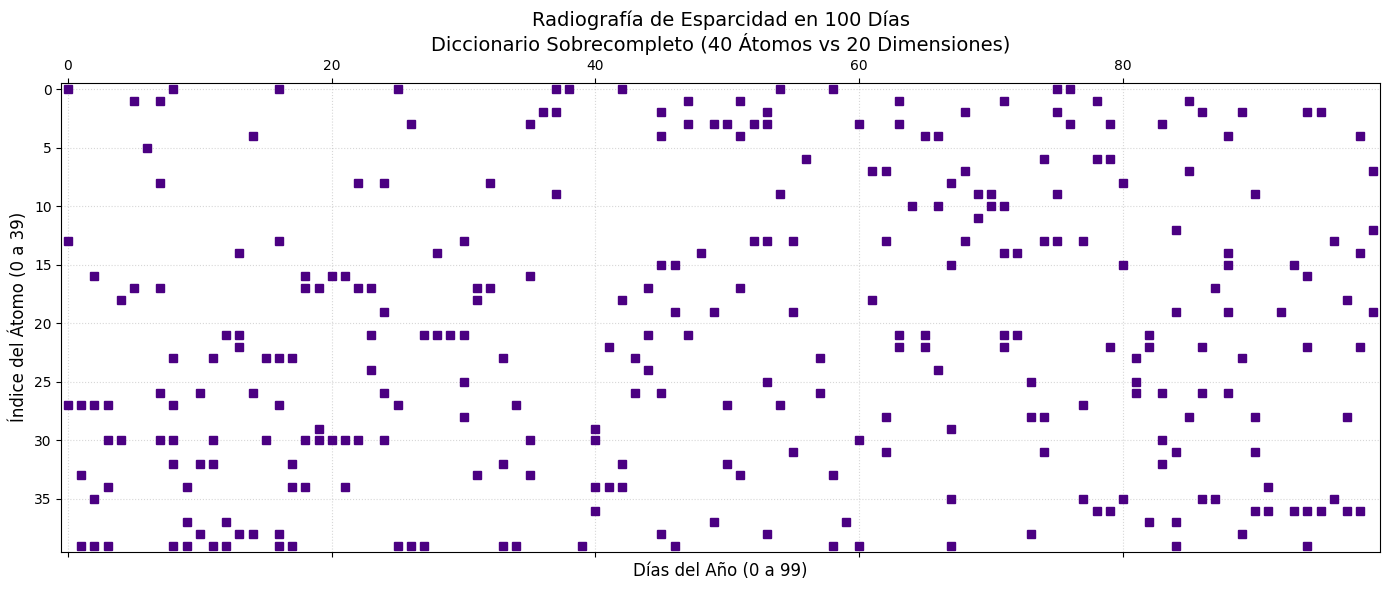

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# ==========================================
# 1) PREPARACIÓN DEL DATASET (20 Dimensiones)
# ==========================================
print("Cargando el dataset de Lincoln...")
url = "https://raw.githubusercontent.com/wilkelab/ggridges/master/data-raw/lincoln-weather.csv"
data = pd.read_csv(url)

# Solo columnas numéricas, quitando días con errores de sensor
X_raw = data.select_dtypes(include=[np.number]).dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

dimension_real = X_scaled.shape[1]
print(f"Dataset listo: {dimension_real} dimensiones físicas detectadas.")
print("-" * 60)

# ==========================================
# 2) ENTRENAMIENTO DEL DICCIONARIO SOBRECOMPLETO
# ==========================================
n_atoms = 40
print(f"Entrenando Diccionario de {n_atoms} átomos (Sobrecompleto)...")

dict_learner = DictionaryLearning(
    n_components=n_atoms, 
    alpha=1.0, 
    transform_algorithm='lasso_lars', 
    random_state=42,
    max_iter=1000
)

# Obtenemos la matriz de coeficientes y los átomos
sparse_representation = dict_learner.fit_transform(X_scaled)
dictionary_atoms = dict_learner.components_

# ==========================================
# 3) CÁLCULO DE MÉTRICAS MATEMÁTICAS EXACTAS
# ==========================================
X_reconstructed = np.dot(sparse_representation, dictionary_atoms)

# Solución exacta sin raíces (MSE puro)
mse_exacto = mean_squared_error(X_scaled, X_reconstructed)

# Porcentaje de ceros estrictos en la matriz
ceros_exactos = np.sum(np.abs(sparse_representation) < 1e-5)
sparsity_pct = (ceros_exactos / sparse_representation.size) * 100

print(f"\nRESULTADOS EXACTOS:")
print(f"MSE Exacto de Reconstrucción: {mse_exacto:.4f}")
print(f"Esparcidad Lograda:           {sparsity_pct:.2f}% de coeficientes son cero absoluto")
print("-" * 60)

# ==========================================
# 4) RADIOGRAFÍA DE LA ESPARCIDAD
# ==========================================
plt.figure(figsize=(14, 6))

# Dibujamos solo los primeros 100 días para que los puntos se vean claros
plt.spy(sparse_representation[:100].T, precision=1e-5, aspect='auto', marker='s', markersize=6, color='indigo')

plt.title(f'Radiografía de Esparcidad en 100 Días\nDiccionario Sobrecompleto ({n_atoms} Átomos vs {dimension_real} Dimensiones)', fontsize=14)
plt.ylabel('Índice del Átomo (0 a 39)', fontsize=12)
plt.xlabel('Días del Año (0 a 99)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

Cargando el dataset de Lincoln...
Dataset listo: 20 dimensiones físicas detectadas.
------------------------------------------------------------
Entrenando Diccionario de 40 átomos...


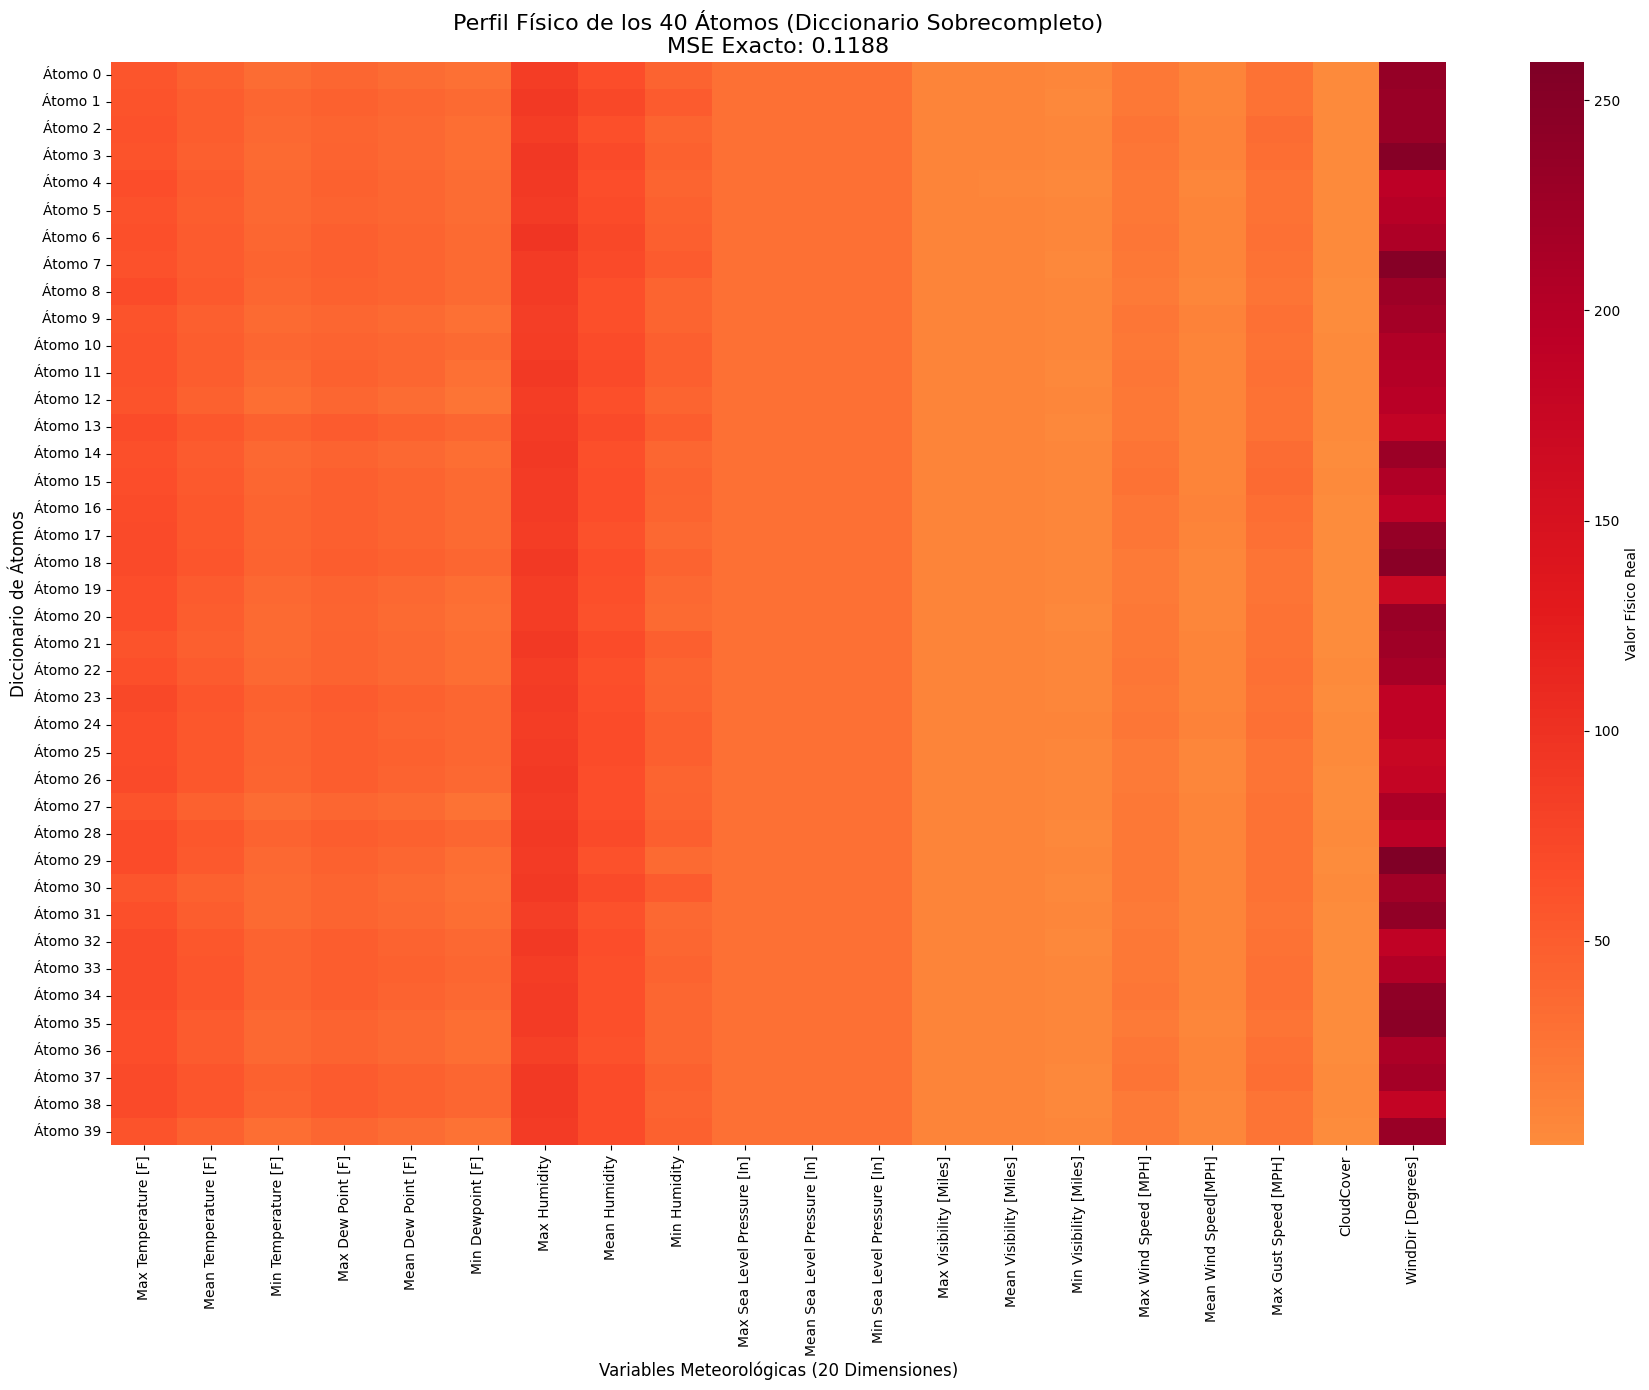

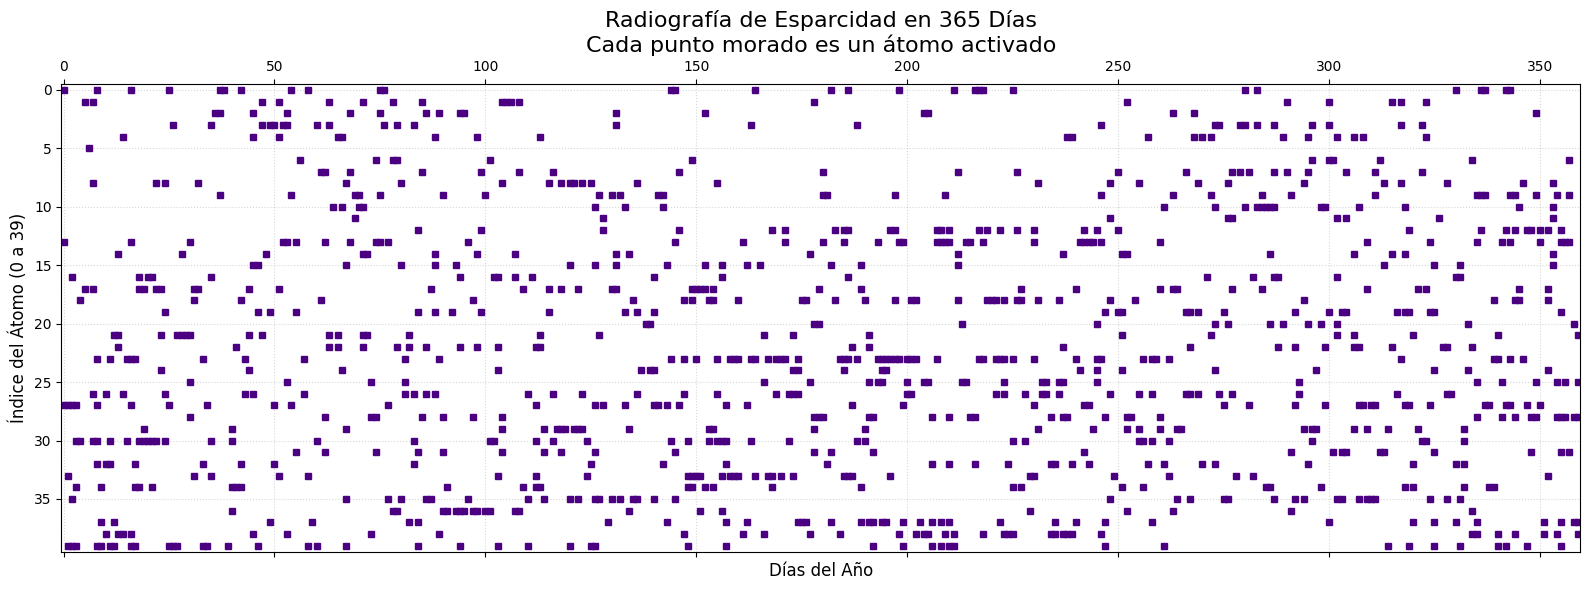

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# ==========================================
# 1) PREPARACIÓN DEL DATASET (20 Dimensiones)
# ==========================================
print("Cargando el dataset de Lincoln...")
url = "https://raw.githubusercontent.com/wilkelab/ggridges/master/data-raw/lincoln-weather.csv"
data = pd.read_csv(url)

# Solo columnas numéricas, quitando nulos
X_raw = data.select_dtypes(include=[np.number]).dropna()
nombres_variables = X_raw.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
dimension_real = X_scaled.shape[1]

print(f"Dataset listo: {dimension_real} dimensiones físicas detectadas.")
print("-" * 60)

# ==========================================
# 2) ENTRENAMIENTO DEL DICCIONARIO SOBRECOMPLETO
# ==========================================
n_atoms = 40
print(f"Entrenando Diccionario de {n_atoms} átomos...")

dict_learner = DictionaryLearning(
    n_components=n_atoms, 
    alpha=1.0, 
    transform_algorithm='lasso_lars', 
    random_state=42,
    max_iter=1000
)

sparse_representation = dict_learner.fit_transform(X_scaled)
dictionary_atoms = dict_learner.components_

# Cálculo del MSE exacto sin raíces
X_reconstructed = np.dot(sparse_representation, dictionary_atoms)
mse_exacto = mean_squared_error(X_scaled, X_reconstructed)

# ==========================================
# 3) TRADUCCIÓN A VALORES FÍSICOS REALES
# ==========================================
# Deshacemos la normalización de los átomos para poder leer grados, humedad, etc.
interpreted_atoms = scaler.inverse_transform(dictionary_atoms)
df_atoms = pd.DataFrame(interpreted_atoms, columns=nombres_variables)
df_atoms.index = [f"Átomo {i}" for i in range(n_atoms)]

# ==========================================
# 4) VISUALIZACIÓN 1: MAPA DE CALOR DE LOS ÁTOMOS
# ==========================================
plt.figure(figsize=(18, 14)) # Tamaño grande para acomodar 40 filas
sns.heatmap(df_atoms, cmap="YlOrRd", center=0, cbar_kws={'label': 'Valor Físico Real'})
plt.title(f"Perfil Físico de los {n_atoms} Átomos (Diccionario Sobrecompleto)\nMSE Exacto: {mse_exacto:.4f}", fontsize=16)
plt.ylabel("Diccionario de Átomos", fontsize=12)
plt.xlabel("Variables Meteorológicas (20 Dimensiones)", fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# 5) VISUALIZACIÓN 2: RADIOGRAFÍA DE ESPARCIDAD (365 DÍAS)
# ==========================================
dias_a_mostrar = 365 # Mostramos un año completo

plt.figure(figsize=(16, 6))
# Usamos un umbral pequeño (1e-5) para los ceros absolutos
plt.spy(sparse_representation[:dias_a_mostrar].T, precision=1e-5, aspect='auto', marker='s', markersize=4, color='indigo')

plt.title(f'Radiografía de Esparcidad en {dias_a_mostrar} Días\nCada punto morado es un átomo activado', fontsize=16)
plt.ylabel('Índice del Átomo (0 a 39)', fontsize=12)
plt.xlabel('Días del Año', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [8]:
# Contamos cuántos átomos se activaron cada día (coeficientes por encima del cero estricto)
atomos_por_dia = np.sum(np.abs(sparse_representation) > 1e-5, axis=1)

# Encontramos el índice del día récord
dia_caotico = np.argmax(atomos_por_dia)

print(f"Día más complejo de reconstruir: Índice {dia_caotico} (Usó {atomos_por_dia[dia_caotico]} átomos simultáneos)")

Día más complejo de reconstruir: Índice 355 (Usó 7 átomos simultáneos)


In [9]:
# Contamos cuántos átomos se activaron cada día (coeficientes por encima del cero estricto)
atomos_por_dia = np.sum(np.abs(sparse_representation) > 1e-5, axis=1)

# Encontramos el índice del día récord
dia_caotico = np.argmax(atomos_por_dia)
cantidad_atomos = atomos_por_dia[dia_caotico]

print("\n" + "="*60)
print(f" ANÁLISIS DEL DÍA MÁS CAÓTICO (Día Índice: {dia_caotico})")
print("="*60)
print(f" Este día necesitó {cantidad_atomos} átomos simultáneos para reconstruirse.")
print(f" Esto minimizó el Error Cuadrático Medio (MSE) exacto, sacrificando la esparcidad.")
print("-" * 60)
print(" VALORES METEOROLÓGICOS FÍSICOS REALES DE ESE DÍA:")
print("-" * 60)

# Mostramos los valores originales puros (sin escalar)
dia_datos_reales = X_raw.iloc[dia_caotico]
print(dia_datos_reales.to_string())
print("="*60 + "\n")


 ANÁLISIS DEL DÍA MÁS CAÓTICO (Día Índice: 355)
 Este día necesitó 7 átomos simultáneos para reconstruirse.
 Esto minimizó el Error Cuadrático Medio (MSE) exacto, sacrificando la esparcidad.
------------------------------------------------------------
 VALORES METEOROLÓGICOS FÍSICOS REALES DE ESE DÍA:
------------------------------------------------------------
Max Temperature [F]              48.00
Mean Temperature [F]             29.00
Min Temperature [F]              10.00
Max Dew Point [F]                22.00
Mean Dew Point [F]               16.00
Min Dewpoint [F]                  7.00
Max Humidity                     84.00
Mean Humidity                    55.00
Min Humidity                     25.00
Max Sea Level Pressure [In]      30.30
Mean Sea Level Pressure [In]     30.13
Min Sea Level Pressure [In]      29.89
Max Visibility [Miles]           10.00
Mean Visibility [Miles]          10.00
Min Visibility [Miles]           10.00
Max Wind Speed [MPH]             18.00
Mean Wind S

Cargando el dataset de Lincoln (Año completo)...
Dataset listo: 360 días detectados con 20 variables.
------------------------------------------------------------
Entrenando Diccionario de 40 átomos y calculando error exacto...


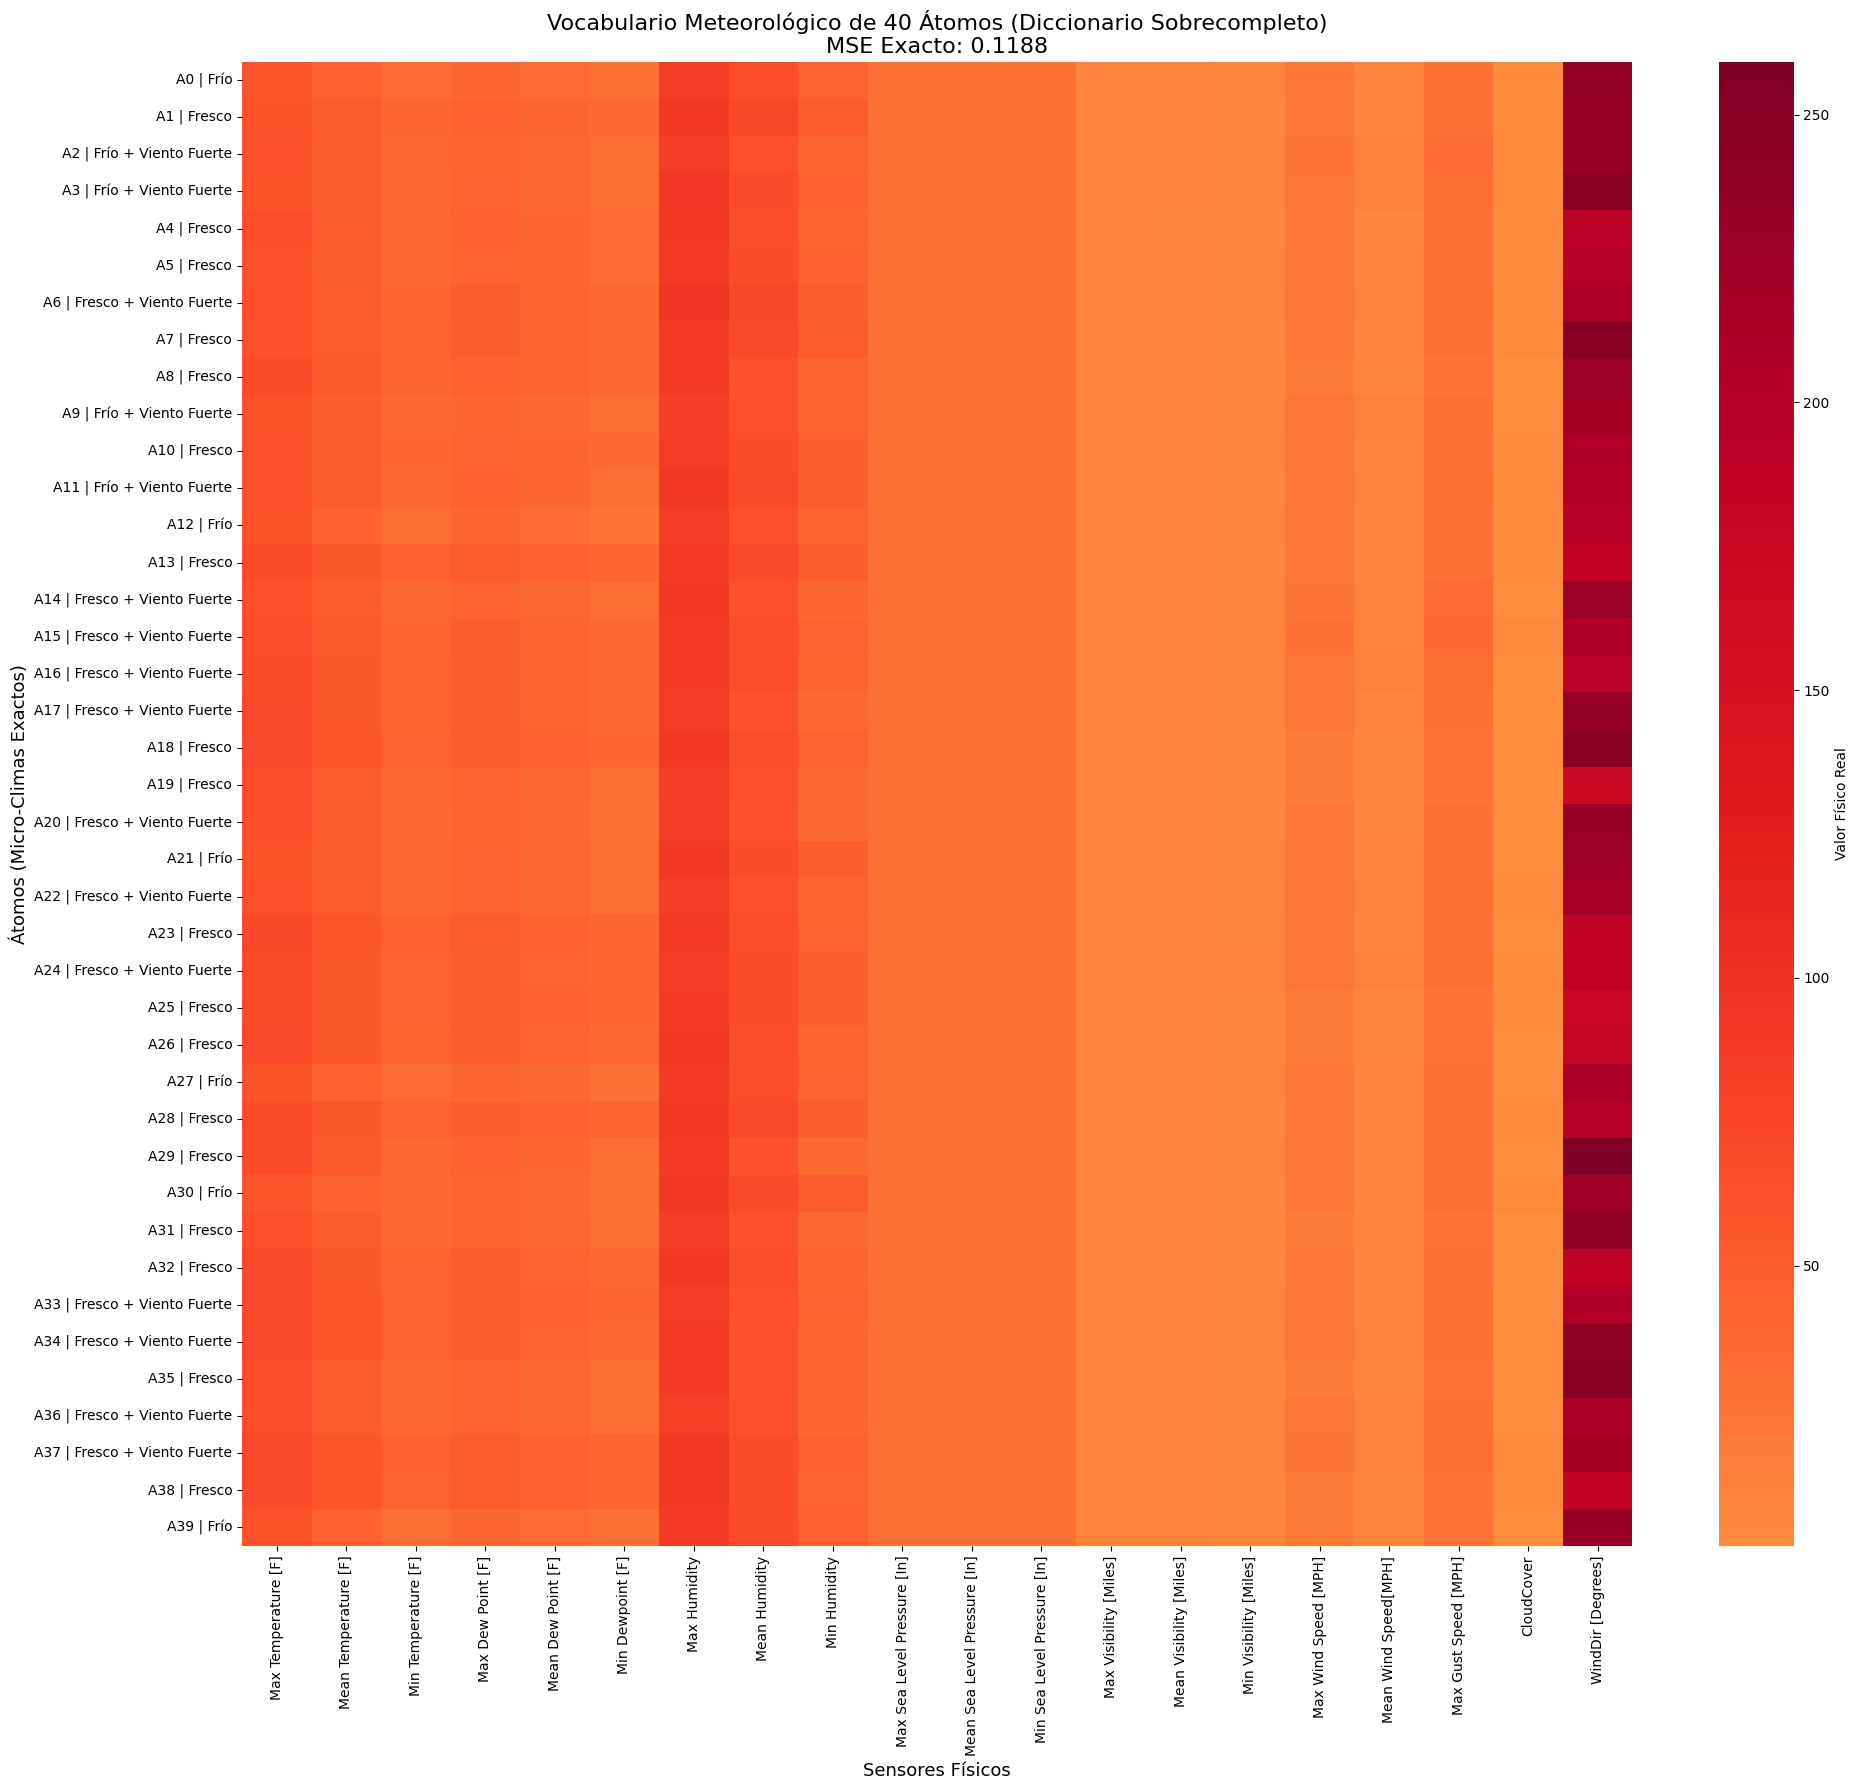

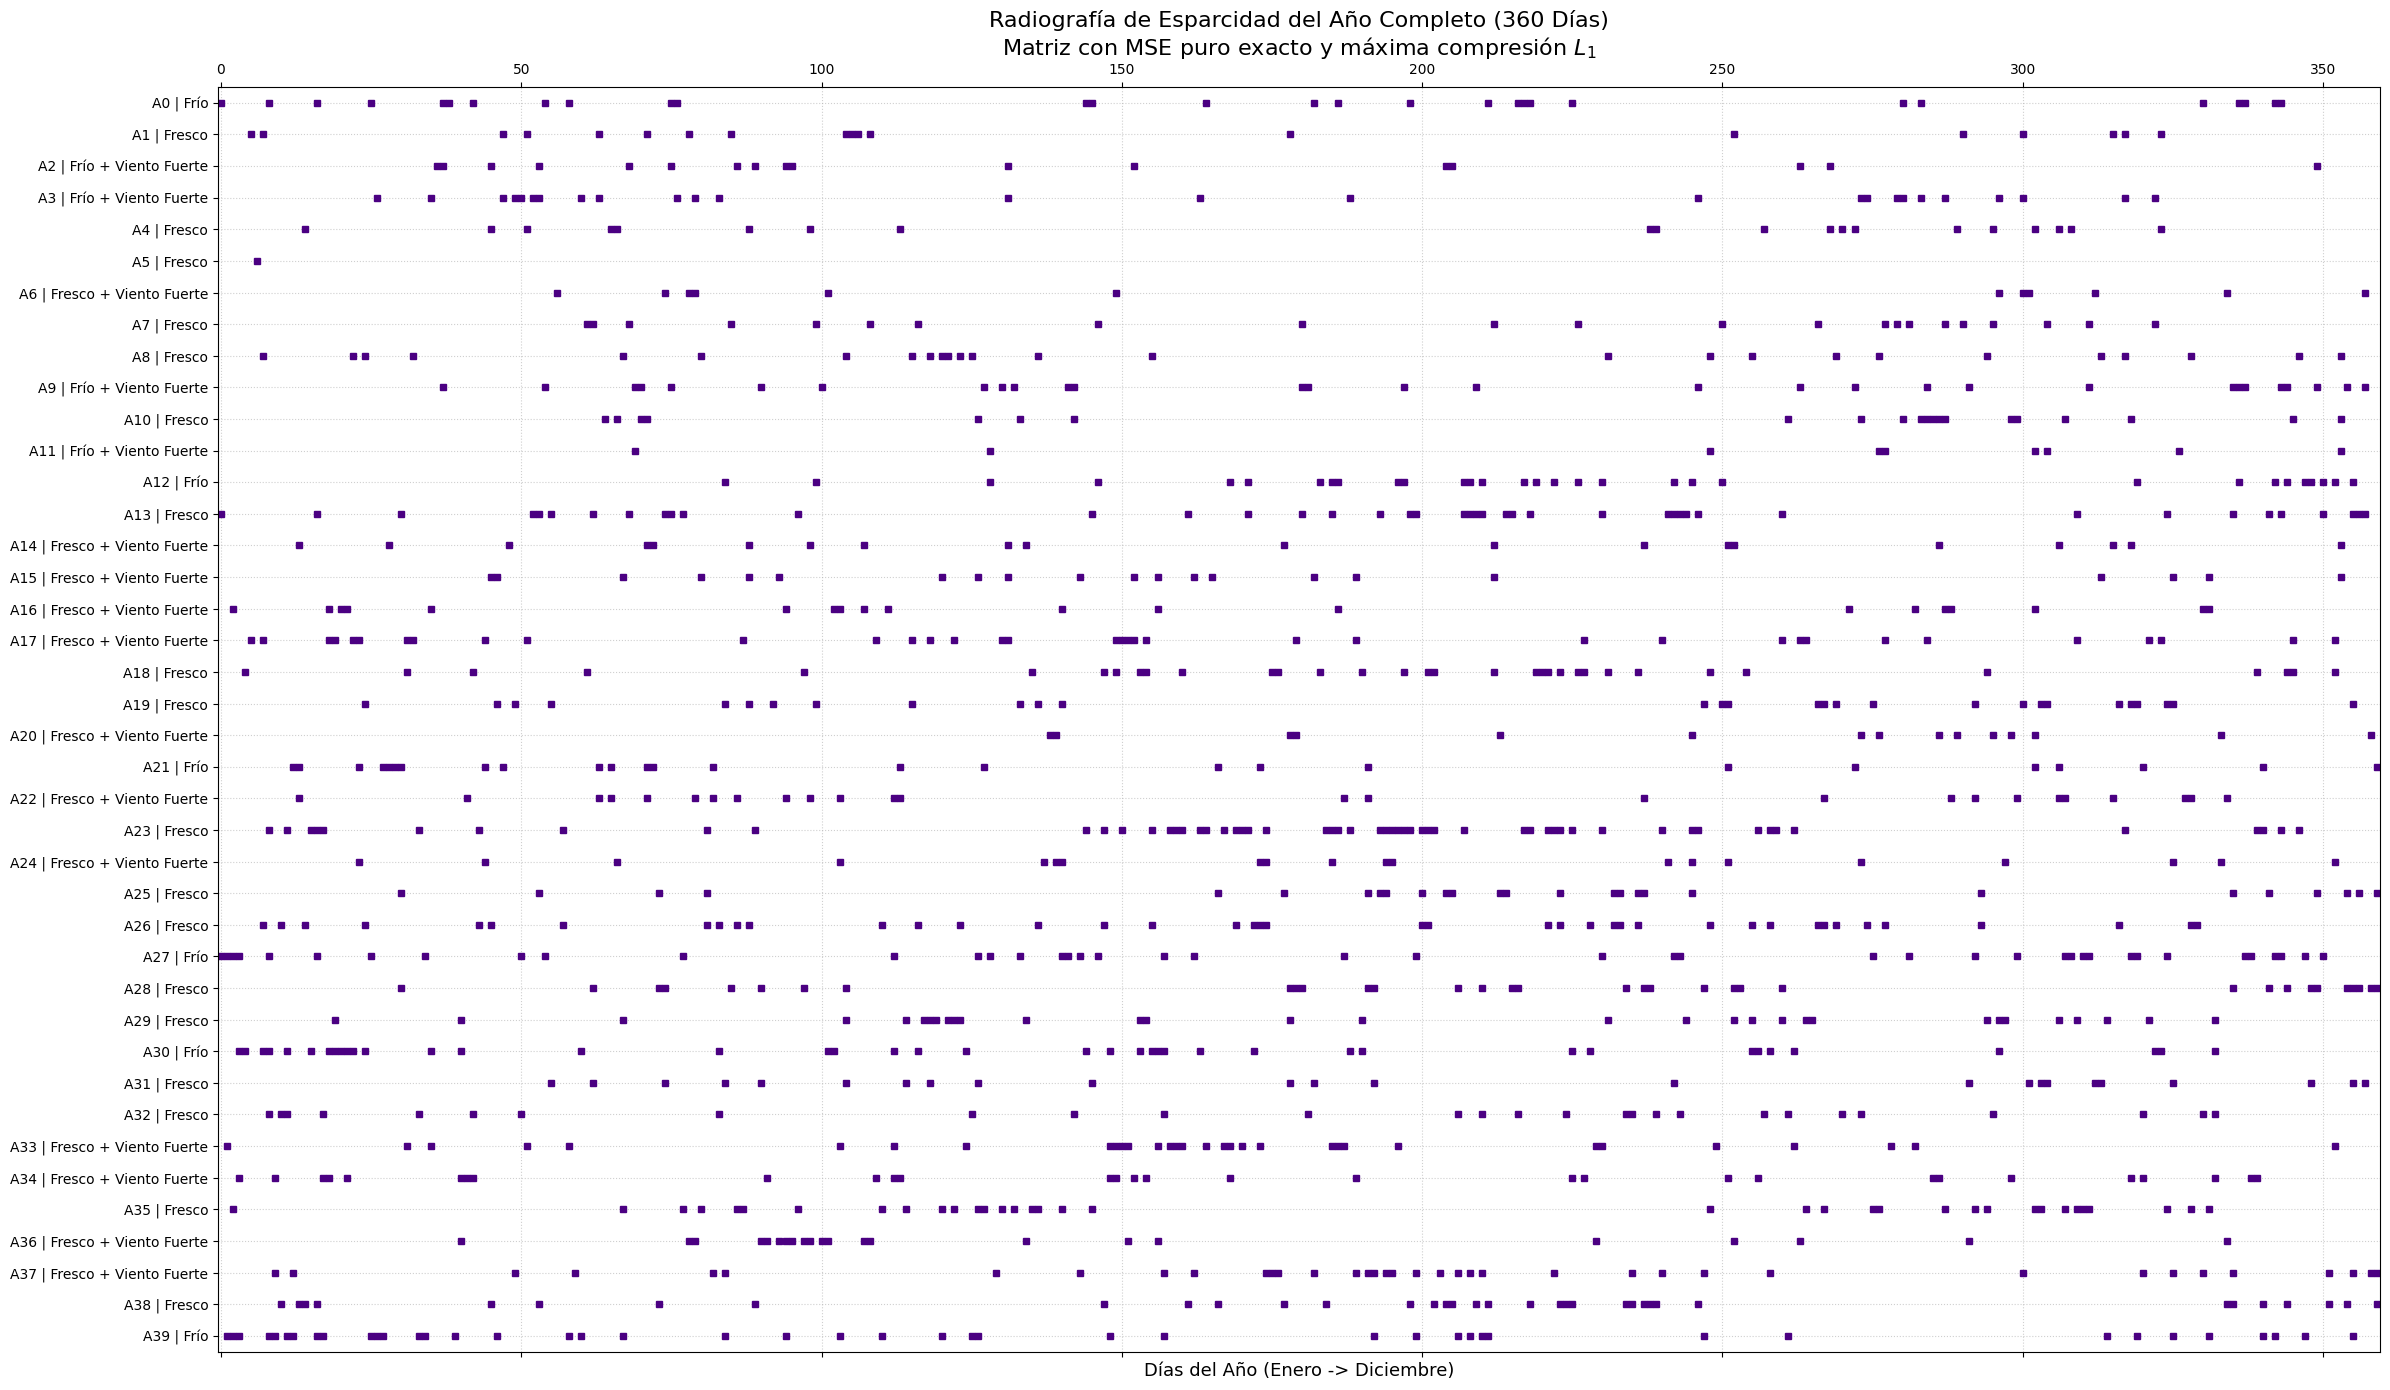

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# ==========================================
# 1) IMPORTACIÓN Y PREPARACIÓN DEL DATASET
# ==========================================
print("Cargando el dataset de Lincoln (Año completo)...")
url = "https://raw.githubusercontent.com/wilkelab/ggridges/master/data-raw/lincoln-weather.csv"
data = pd.read_csv(url)

# Solo columnas numéricas, quitando nulos
X_raw = data.select_dtypes(include=[np.number]).dropna()
nombres_variables = X_raw.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

dias_totales = X_scaled.shape[0]
print(f"Dataset listo: {dias_totales} días detectados con {X_scaled.shape[1]} variables.")
print("-" * 60)

# ==========================================
# 2) ENTRENAMIENTO DEL DICCIONARIO (40 ÁTOMOS)
# ==========================================
n_atoms = 40
print(f"Entrenando Diccionario de {n_atoms} átomos y calculando error exacto...")

dict_learner = DictionaryLearning(
    n_components=n_atoms, 
    alpha=1.0, 
    transform_algorithm='lasso_lars', 
    random_state=42,
    max_iter=1000
)

sparse_representation = dict_learner.fit_transform(X_scaled)
dictionary_atoms = dict_learner.components_

# MSE Exacto matemático (sin raíces)
X_reconstructed = np.dot(sparse_representation, dictionary_atoms)
mse_exacto = mean_squared_error(X_scaled, X_reconstructed)

# ==========================================
# 3) TRADUCCIÓN A VALORES FÍSICOS REALES
# ==========================================
interpreted_atoms = scaler.inverse_transform(dictionary_atoms)
df_atoms = pd.DataFrame(interpreted_atoms, columns=nombres_variables)

# --- EL AUTÓMATA METEOROLÓGICO DE ALTA PRECISIÓN ---
def etiquetar_atomo_detallado(row):
    etiquetas = []
    
    # 1. TEMPERATURA
    col_temp = [c for c in row.index if "Temperature" in c and "Mean" in c]
    if col_temp:
        temp = row[col_temp[0]]
        if temp < 32: etiquetas.append("Helada")
        elif temp < 50: etiquetas.append("Frío")
        elif temp < 65: etiquetas.append("Fresco")
        elif temp < 80: etiquetas.append("Cálido")
        else: etiquetas.append("Calor Intenso")
            
    # 2. PRECIPITACIÓN
    col_lluvia = [c for c in row.index if "Precipitation" in c]
    if col_lluvia:
        lluvia = row[col_lluvia[0]]
        if lluvia > 0.6: etiquetas.append("Tormenta")
        elif lluvia > 0.15: etiquetas.append("Lluvia Moderada")
        elif lluvia > 0.01: etiquetas.append("Llovizna")
        else: etiquetas.append("Seco")
            
    # 3. VIENTO
    col_viento = [c for c in row.index if "Wind" in c and "Max" in c]
    if col_viento:
        viento = row[col_viento[0]]
        if viento > 35: etiquetas.append("Vendaval")
        elif viento > 22: etiquetas.append("Viento Fuerte")
        elif viento < 12: etiquetas.append("Sin Viento")
            
    # 4. HUMEDAD
    col_hum = [c for c in row.index if "Humidity" in c and "Mean" in c]
    if col_hum:
        hum = row[col_hum[0]]
        if hum > 85: etiquetas.append("Muy Húmedo")
        elif hum < 45: etiquetas.append("Ambiente Seco")

    if not etiquetas:
        return "Día Neutro"
    
    return " + ".join(etiquetas)

nombres_etiquetados = []
for i, row in df_atoms.iterrows():
    nombre_base = etiquetar_atomo_detallado(row)
    nombres_etiquetados.append(f"A{i} | {nombre_base}")

df_atoms.index = nombres_etiquetados

# ==========================================
# 4) MAPA DE CALOR ETIQUETADO DETALLADO
# ==========================================
plt.figure(figsize=(20, 18)) 
sns.heatmap(df_atoms, cmap="YlOrRd", center=0, cbar_kws={'label': 'Valor Físico Real'})
plt.title(f"Vocabulario Meteorológico de 40 Átomos (Diccionario Sobrecompleto)\nMSE Exacto: {mse_exacto:.4f}", fontsize=16)
plt.ylabel("Átomos (Micro-Climas Exactos)", fontsize=13)
plt.xlabel("Sensores Físicos", fontsize=13)
plt.tight_layout()
plt.show()

# ==========================================
# 5) RADIOGRAFÍA DE ESPARCIDAD (AÑO COMPLETO)
# ==========================================
# Ampliamos la gráfica a todo lo ancho para que entren los 366 días sin pisarse
plt.figure(figsize=(24, 14))

# Le pasamos la matriz entera (.T) sin el límite de días
plt.spy(sparse_representation.T, precision=1e-5, aspect='auto', marker='s', markersize=4, color='indigo')

plt.yticks(ticks=range(n_atoms), labels=nombres_etiquetados, fontsize=10)

plt.title(f'Radiografía de Esparcidad del Año Completo ({dias_totales} Días)\nMatriz con MSE puro exacto y máxima compresión $L_1$', fontsize=16)
plt.xlabel('Días del Año (Enero -> Diciembre)', fontsize=13)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [12]:
# ==========================================
# 6) EXTRACCIÓN Y VISUALIZACIÓN DE LA MATRIZ MATEMÁTICA
# ==========================================
print("\n" + "="*60)
print(" EXTRAYENDO LA MATRIZ DE COEFICIENTES (MATRIZ ESPARSA)")
print("="*60)

# Convertimos la matriz numpy a un DataFrame de Pandas para que sea legible
# Las filas serán los Días, las columnas serán los 40 Átomos
columnas_atomos = [f"Átomo {i}" for i in range(n_atoms)]
df_matriz_esparsa = pd.DataFrame(sparse_representation, columns=columnas_atomos)
df_matriz_esparsa.index = [f"Día {i+1}" for i in range(dias_totales)]

# Redondeamos a 4 decimales exactos para ver bien los ceros absolutos
df_matriz_esparsa = df_matriz_esparsa.round(4)

# 1. Filtramos y mostramos en consola SOLO los primeros 5 días
# y solo los átomos que se encendieron (para que quepa en la pantalla)
dias_muestra = df_matriz_esparsa.head(5)
atomos_activos_muestra = dias_muestra.columns[(dias_muestra != 0).any()]

print("\nRadiografía numérica de los primeros 5 días (Solo átomos que se usaron):")
print("-" * 60)
print(dias_muestra[atomos_activos_muestra].to_string())
print("-" * 60)
print("Nota: El resto de los 40 átomos (no mostrados aquí) tienen un valor exacto de 0.0000")

# 2. Guardamos la matriz completa en tu Mac para que la abras en Excel
nombre_archivo = "matriz_esparsa_coeficientes.csv"
df_matriz_esparsa.to_csv(nombre_archivo)

print(f"\n[ÉXITO] Matriz completa guardada como '{nombre_archivo}' en tu carpeta actual.")
print("¡Abre este archivo en Excel para enseñarle al profesor el mar de ceros exactos!")
print("="*60 + "\n")


 EXTRAYENDO LA MATRIZ DE COEFICIENTES (MATRIZ ESPARSA)

Radiografía numérica de los primeros 5 días (Solo átomos que se usaron):
------------------------------------------------------------
       Átomo 0  Átomo 13  Átomo 16  Átomo 18  Átomo 27  Átomo 30  Átomo 33  Átomo 34  Átomo 35  Átomo 39
Día 1   0.1619   -0.1291    0.0000    0.0000    3.6614    0.0000    0.0000    0.0000    0.0000    0.0000
Día 2   0.0000    0.0000    0.0000    0.0000    1.4193    0.0000   -0.2035    0.0000    0.0000    2.3344
Día 3   0.0000    0.0000   -0.2716    0.0000    2.2161    0.0000    0.0000    0.0000    0.3203    1.8830
Día 4   0.0000    0.0000    0.0000    0.0000    1.9386    0.6992    0.0000   -1.6587    0.0000    0.4371
Día 5   0.0000    0.0000    0.0000   -0.1978    0.0000    2.3272    0.0000    0.0000    0.0000    0.0000
------------------------------------------------------------
Nota: El resto de los 40 átomos (no mostrados aquí) tienen un valor exacto de 0.0000

[ÉXITO] Matriz completa guardada